In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import requests
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu128
GPU available: True


In [ ]:
url = "https://www.sidc.be/SILSO/DATA/SN_m_tot_V2.0.txt"
response = requests.get(url)
lines = response.text.strip().split("\n")

In [ ]:
sunspots = []
for line in lines:
    parts = line.split()
    if len(parts) >= 4:
        value = float(parts[3])
        if value >= 0:
            sunspots.append(value)


data = np.array(sunspots, dtype=np.float32)
print(f"Loaded {len(data)} monthly observations")
print(f"Min: {data.min():.1f}, Max: {data.max():.1f}, Mean: {data.mean():.1f}")

Loaded 3329 monthly observations
Min: 0.0, Max: 398.2, Mean: 82.2


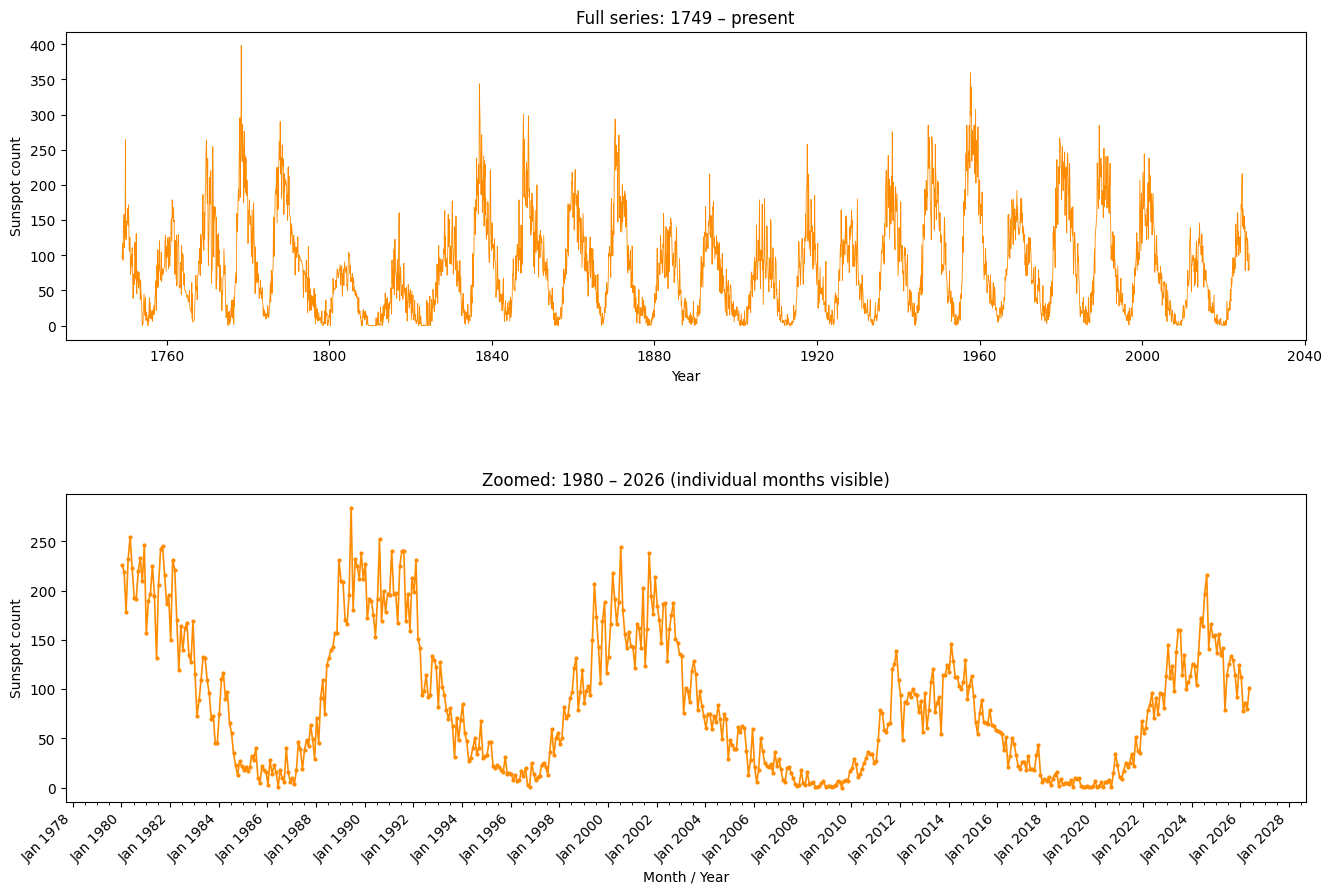

In [ ]:
import datetime
import matplotlib.dates as mdates

# Build proper monthly dates
start = datetime.date(1749, 1, 1)
dates = [start + datetime.timedelta(days=30.44 * i) for i in range(len(data))]

# --- Plot 1: Full series ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
fig.subplots_adjust(hspace=0.5)

ax1.plot(dates, data, linewidth=0.6, color='darkorange')
ax1.set_title("Full series: 1749 – present")
ax1.set_xlabel("Year")
ax1.set_ylabel("Sunspot count")

# --- Plot 2: Zoomed into 1980–2026 ---
zoom_start = datetime.date(1980, 1, 1)
zoom_end   = datetime.date(2026, 12, 1)

zoom_dates = [d for d in dates if zoom_start <= d <= zoom_end]
zoom_data  = [data[i] for i, d in enumerate(dates) if zoom_start <= d <= zoom_end]

ax2.plot(zoom_dates, zoom_data, linewidth=1.2, color='darkorange', marker='o', markersize=2)
ax2.set_title("Zoomed: 1980 – 2026 (individual months visible)")
ax2.set_xlabel("Month / Year")
ax2.set_ylabel("Sunspot count")

ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.show()

In [ ]:
data_min = data.min()
data_max = data.max()
data_norm = (data - data_min) / (data_max - data_min)
print(f"Original range: {data_min:.1f} to {data_max:.1f}")
print(f"Normalized range: {data_norm.min():.4f} to {data_norm.max():.4f}")

Original range: 0.0 to 398.2
Normalized range: 0.0000 to 1.0000


In [ ]:
CONTEXT_LENGTH = 128


def make_sequences(data, context_length):
    X, y = [], []
    for i in range(len(data) - context_length):
        X.append(data[i : i + context_length])
        y.append(data[i + context_length])
    X = torch.tensor(np.array(X), dtype=torch.float32)
    y = torch.tensor(np.array(y), dtype=torch.float32)
    return X, y





In [ ]:
X, y = make_sequences(data_norm, CONTEXT_LENGTH)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Total examples: {X.shape[0]}")

X shape: torch.Size([3201, 128])
y shape: torch.Size([3201])
Total examples: 3201


In [ ]:
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print(f"Train: {X_train.shape[0]} sequences")
print(f"Val:   {X_val.shape[0]} sequences")

Train: 2560 sequences
Val:   641 sequences


In [ ]:
d_model = 64
class SunspotEmbedding(nn.Module):
  def __init__(self, d_model):
        super().__init__()
        self.linear = nn.Linear(1, d_model)
        self.activation = nn.GELU()
  def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.linear(x)
        x = self.activation(x)
        return x
embedding = SunspotEmbedding(d_model)
print(embedding)


SunspotEmbedding(
  (linear): Linear(in_features=1, out_features=64, bias=True)
  (activation): GELU(approximate='none')
)


In [ ]:
test_input = X_train[:2]
test_output = embedding(test_input)
print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {test_output.shape}")

Input shape:  torch.Size([2, 128])
Output shape: torch.Size([2, 128, 64])


positional encoding:


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            -(np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x

In [ ]:
pos_encoding = PositionalEncoding(d_model)
test_pe_output = pos_encoding(test_output)
print(f"After positional encoding: {test_pe_output.shape}")

After positional encoding: torch.Size([2, 128, 64])


Self Attention

In [ ]:
n_heads = 4
head_dim = d_model // n_heads

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch, seq_len, d_model = x.shape
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        Q = Q.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        scores = scores.masked_fill(mask.to(x.device), float('-inf'))
        weights = torch.softmax(scores, dim=-1)
        attended = torch.matmul(weights, V)
        attended = attended.transpose(1, 2).contiguous().view(batch, seq_len, d_model)
        output = self.W_o(attended)
        return output

attention = SelfAttention(d_model, n_heads)
test_attn_output = attention(test_pe_output)
print(f"After self-attention: {test_attn_output.shape}")

After self-attention: torch.Size([2, 128, 64])


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, ff_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, d_model)
        )

    def forward(self, x):
        return self.net(x)

ff = FeedForward(d_model)
test_ff_output = ff(test_attn_output)
print(f"After feedforward: {test_ff_output.shape}")

After feedforward: torch.Size([2, 128, 64])


In [ ]:
class SunspotTransformer(nn.Module):
    def __init__(self, d_model, n_heads, n_layers=2, ff_dim=256):
        super().__init__()
        self.embedding = SunspotEmbedding(d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.attention_layers = nn.ModuleList([
            SelfAttention(d_model, n_heads) for _ in range(n_layers)
        ])
        self.ff_layers = nn.ModuleList([
            FeedForward(d_model, ff_dim) for _ in range(n_layers)
        ])
        self.norm_layers = nn.ModuleList([
            nn.LayerNorm(d_model) for _ in range(n_layers * 2)
        ])
        self.output_head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        for i in range(len(self.attention_layers)):
            attn_out = self.attention_layers[i](x)
            x = self.norm_layers[i*2](x + attn_out)
            ff_out = self.ff_layers[i](x)
            x = self.norm_layers[i*2+1](x + ff_out)
        x = x[:, -1, :]
        output = self.output_head(x)
        output = output.squeeze(-1)
        return output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SunspotTransformer(d_model=64, n_heads=4, n_layers=2, ff_dim=256)
model = model.to(device)

test = X_train[:2].to(device)
out = model(test)
print(f"Model output shape: {out.shape}")
print(f"Sample prediction: {out[0].item():.4f}")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Model output shape: torch.Size([2])
Sample prediction: 0.0969
Total parameters: 100,161


Epoch  10/50 | Train Loss: 0.004330 | Val Loss: 0.003179
Epoch  20/50 | Train Loss: 0.004045 | Val Loss: 0.003200
Epoch  30/50 | Train Loss: 0.003983 | Val Loss: 0.003235
Epoch  40/50 | Train Loss: 0.004262 | Val Loss: 0.003372
Epoch  50/50 | Train Loss: 0.004139 | Val Loss: 0.003103


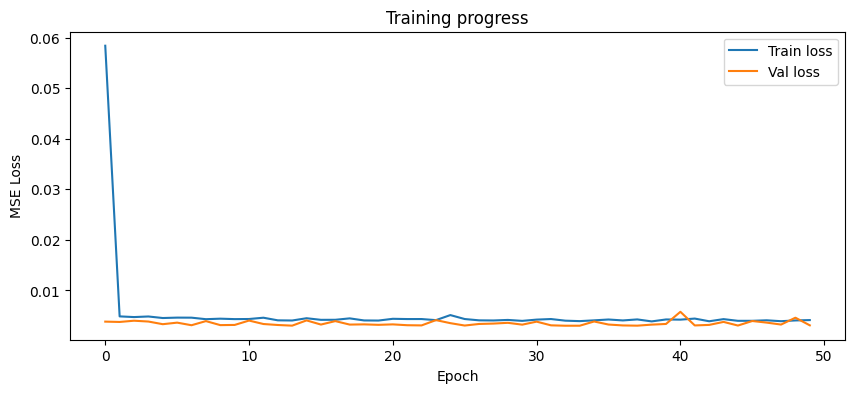

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset_train = TensorDataset(X_train, y_train)
dataset_val = TensorDataset(X_val, y_val)

train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=32, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 50
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val.to(device))
        val_loss = criterion(val_preds, y_val.to(device)).item()
        val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/50 | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training progress')
plt.legend()
plt.show()

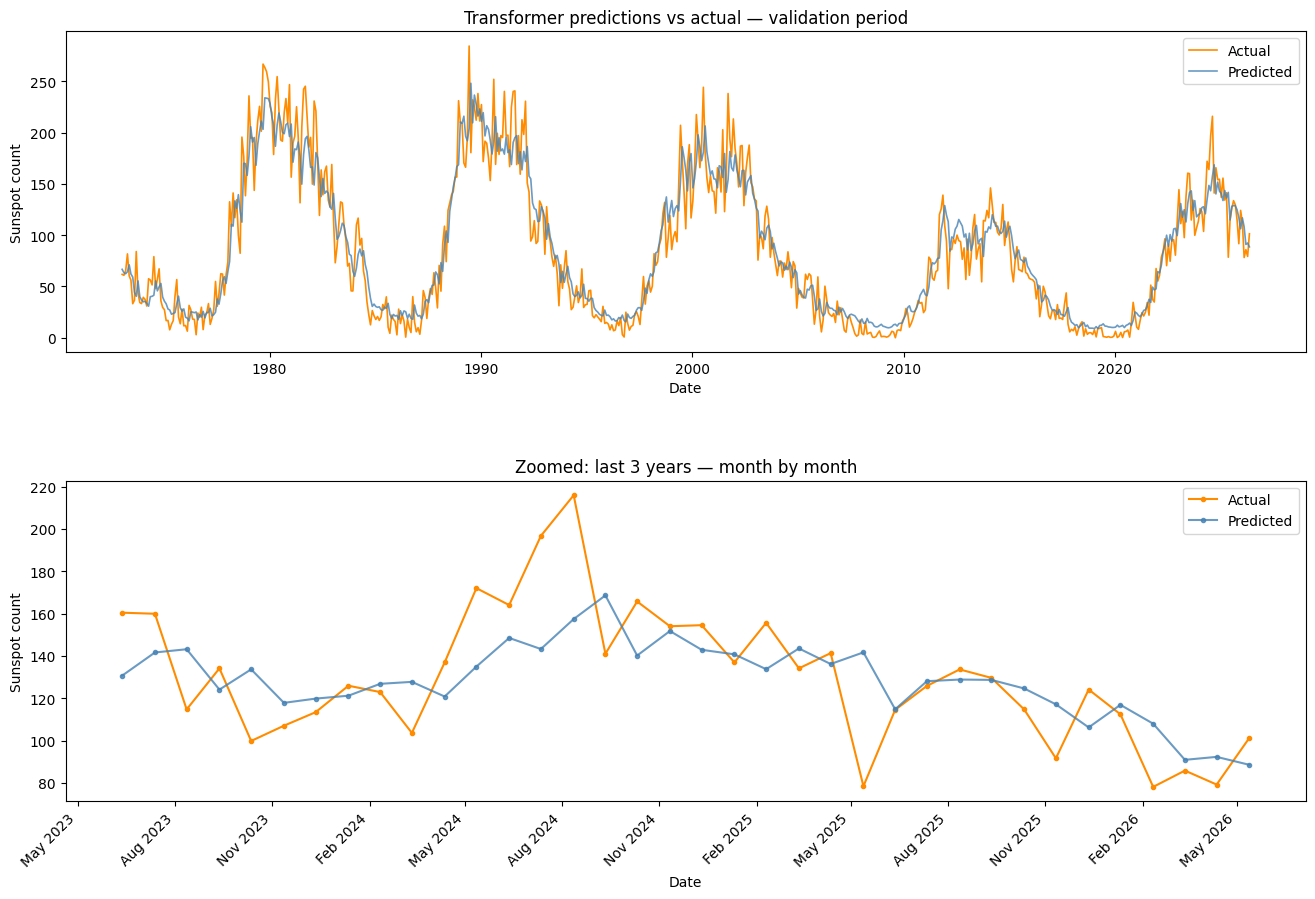

Mean Absolute Error: 16.4 sunspots
Validation period: Jan 1973 to May 2026


In [ ]:
model.eval()
with torch.no_grad():
    val_predictions = model(X_val.to(device)).cpu().numpy()
    val_actual = y_val.numpy()

val_predictions_real = val_predictions * (data_max - data_min) + data_min
val_actual_real = val_actual * (data_max - data_min) + data_min

total_months = len(data)
val_start_idx = split + CONTEXT_LENGTH
val_dates = dates[val_start_idx : val_start_idx + len(val_predictions)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
fig.subplots_adjust(hspace=0.4)

ax1.plot(val_dates, val_actual_real, color='darkorange', linewidth=1.2, label='Actual')
ax1.plot(val_dates, val_predictions_real, color='steelblue', linewidth=1.2, label='Predicted', alpha=0.8)
ax1.set_title('Transformer predictions vs actual — validation period')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sunspot count')
ax1.legend()

zoom_n = 36
ax2.plot(val_dates[-zoom_n:], val_actual_real[-zoom_n:], color='darkorange', linewidth=1.5, label='Actual', marker='o', markersize=3)
ax2.plot(val_dates[-zoom_n:], val_predictions_real[-zoom_n:], color='steelblue', linewidth=1.5, label='Predicted', alpha=0.8, marker='o', markersize=3)
ax2.set_title('Zoomed: last 3 years — month by month')
ax2.set_xlabel('Date')
ax2.set_ylabel('Sunspot count')
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax2.legend()

plt.show()

mae = np.mean(np.abs(val_predictions_real - val_actual_real))
print(f"Mean Absolute Error: {mae:.1f} sunspots")
print(f"Validation period: {val_dates[0].strftime('%b %Y')} to {val_dates[-1].strftime('%b %Y')}")